# **EDA: Demografica**

In [1]:
# --- librerias --- #

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from pathlib import Path

# --- set cwd --- #
ROOT = Path().cwd().parent
os.chdir(ROOT)

In [2]:
# --- Leemos las bases --- #
labels = (
    pd.read_parquet(
        r'data\raw\labels_27-09-2026.parquet', 
        engine='pyarrow',
    )
)

demografica = (
    pd.read_parquet(
        r'data\raw\demografica_27-09-2026.parquet', 
        engine='pyarrow',
    )
)

In [3]:
# --- merge --- #

df = (
    labels
    .merge(
        demografica, 
        how='left', 
        on=['strIdentificacion','strPeriodo'], 
    )
)

df.head()

,strPeriodo,strIdentificacion,strEstadoInicial,IndicadorReactivado,demo_Tipo_Documento,demo_Tipo_Vinculacion,demo_Estado_Civil,demo_Personas_a_Cargo,demo_Personas_a_Cargo_Menores_18,demo_Sexo,...,demo_Ingresos,demo_Egresos,demo_Nombre_Ocupacion,demo_Ptaje_acierta,demo_Cuotas_canceladas_aportes,demo_Saldoaportes,demo_Segmento_Ciclo_de_Vida,demo_Edad,demo_Antiguedad,demo_suma_productos
0,202507,1020742609,14,0,CC,Familiar Asociado,Soltero,0.0,0.0,F,...,1125000.0,1125000.0,Independiente,0.0,169.0,6166125.0,Mujer Independiente,36.0,18.02,0.0
1,202507,29681299,14,0,CC,Profesional,Soltero,0.0,0.0,F,...,2250000.0,1125000.0,Independiente,771.0,5.0,39850.0,Transicion,42.0,8.31,0.0
2,202507,26258932,14,0,CC,Mayor 60,Soltero,0.0,1.0,F,...,10156864.0,NaN,Asalariado,0.0,178.0,5571696.0,Maduro,67.0,23.51,4.0
3,202507,1017159835,14,0,CC,Técnicos y Tecnólogos,Soltero,0.0,0.0,M,...,10323260.0,NaN,Asalariado,782.0,34.0,991769.0,Transicion,37.0,3.34,2.0
4,202507,29124875,14,0,CC,Profesional,Soltero,0.0,3.0,F,...,2250000.0,2250000.0,Independiente,851.0,78.0,3255307.0,Consolidacion,45.0,8.89,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 997847 entries, 0 to 997846
Data columns (total 23 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   strPeriodo                        997847 non-null  int64  
 1   strIdentificacion                 997847 non-null  int64  
 2   strEstadoInicial                  997847 non-null  Int64  
 3   IndicadorReactivado               997847 non-null  int64  
 4   demo_Tipo_Documento               997847 non-null  str    
 5   demo_Tipo_Vinculacion             997847 non-null  str    
 6   demo_Estado_Civil                 997847 non-null  str    
 7   demo_Personas_a_Cargo             997847 non-null  float64
 8   demo_Personas_a_Cargo_Menores_18  997847 non-null  float64
 9   demo_Sexo                         997847 non-null  str    
 10  demo_Estrato                      997847 non-null  str    
 11  demo_Nombre_Tipo_Vivienda         997847 non-null  str    
 12 

In [5]:
df.columns.tolist()

['strPeriodo',
 'strIdentificacion',
 'strEstadoInicial',
 'IndicadorReactivado',
 'demo_Tipo_Documento',
 'demo_Tipo_Vinculacion',
 'demo_Estado_Civil',
 'demo_Personas_a_Cargo',
 'demo_Personas_a_Cargo_Menores_18',
 'demo_Sexo',
 'demo_Estrato',
 'demo_Nombre_Tipo_Vivienda',
 'demo_Nombre_Nivel_Academico',
 'demo_Ingresos',
 'demo_Egresos',
 'demo_Nombre_Ocupacion',
 'demo_Ptaje_acierta',
 'demo_Cuotas_canceladas_aportes',
 'demo_Saldoaportes',
 'demo_Segmento_Ciclo_de_Vida',
 'demo_Edad',
 'demo_Antiguedad',
 'demo_suma_productos']

In [6]:
dist_Tipo_Documento = (
    df.groupby(['demo_Tipo_Documento', 'IndicadorReactivado'])
      .size()
      .reset_index(name='counts')
      .assign(pct=lambda x: (
          x['counts'] / x.groupby('demo_Tipo_Documento')['counts'].transform('sum') * 100
      ).round(2))
)
dist_Tipo_Documento

,demo_Tipo_Documento,IndicadorReactivado,counts,pct
0,CC,0,958387,98.23
1,CC,1,17247,1.77
2,CE,0,3522,98.71
3,CE,1,46,1.29
4,NIT,0,18423,99.59
5,NIT,1,75,0.41
6,PPT,0,11,100.00
7,PS,0,115,97.46
8,PS,1,3,2.54
9,SI,0,16,100.00


Nos quedamos con CC y CE (personas naturales). Se excluye NIT por ser empresa o vinculación a través de una, lo que dificulta el contacto, y los demás tipos por su bajo volumen.

In [7]:
#----Clasificación de las variables----#

COLS_CATEGORICAS = [
    'demo_Tipo_Documento',
    'demo_Tipo_Vinculacion',
    'demo_Estado_Civil',
    'demo_Sexo',
    'demo_Nombre_Tipo_Vivienda',
    'demo_Nombre_Nivel_Academico',
    'demo_Nombre_Ocupacion',
    'demo_Segmento_Ciclo_de_Vida',
]

COLS_DISCRETAS = {
    'demo_Estrato': None,
    'demo_Personas_a_Cargo': None,
    'demo_Personas_a_Cargo_Menores_18': None,
    'demo_suma_productos': None,
}
 
COLS_NUMERICAS = [
    'demo_Ingresos',
    'demo_Egresos',
    'demo_Saldoaportes',
    'demo_Cuotas_canceladas_aportes',
    'demo_Edad',
    'demo_Antiguedad',
    'demo_Ptaje_acierta',
]


TARGET = 'IndicadorReactivado'

In [9]:
# ---- Funciones para generar tablas y gráficas ----- #

def tabla_tasa(df, col, target=TARGET):
    """Tabla con volumen y tasa de reactivación por cada valor de `col`."""
    tabla = (
        df.groupby(col, dropna=False, observed=True)[target]
          .agg(n='size', reactivados='sum')
          .reset_index()
    )
    tabla['pct_poblacion'] = tabla['n'] / tabla['n'].sum() * 100
    tabla['tasa_reactivacion'] = tabla['reactivados'] / tabla['n'] * 100
    return tabla.round(2)
 
 
def graficar_tasa(tabla, col, tasa_global, titulo=None):
    """Barras con la tasa por grupo + línea de la tasa global y n en cada barra."""
    etiquetas = tabla[col].astype(str)
    fig, ax = plt.subplots(figsize=(max(6, len(tabla) * 0.9), 4.5))
    barras = ax.bar(etiquetas, tabla['tasa_reactivacion'], color='steelblue')
    ax.axhline(tasa_global, color='red', ls='--',
               label=f'Tasa global ({tasa_global:.2f}%)')
 
    for barra, n in zip(barras, tabla['n']):
        ax.annotate(f'n={n:,}',
                    (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    ha='center', va='bottom', fontsize=8)
 
    ax.set_ylabel('Tasa de reactivación (%)')
    ax.set_title(titulo or f'Tasa de reactivación por {col}')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
 
 
def _fmt(v):
    """Formato legible para los cortes de cuantiles."""
    return f'{v:,.0f}' if abs(v) >= 100 else f'{v:,.2f}'

In [ ]:
## ---- Función completa categóricas y discretas ---- ##


def _tope_automatico(x, min_pct):
    """
    Para discretas: recorre los valores de mayor a menor acumulando su peso
    hasta que la cola sume al menos `min_pct`. Ese valor es el tope.
    """
    pct = x.value_counts(normalize=True).sort_index(ascending=False) * 100
    acumulado = pct.cumsum()
    candidatos = acumulado[acumulado >= min_pct]
    if candidatos.empty:
        return None
    tope = candidatos.index[0]
    # Si el tope es el valor máximo, no hay cola que agrupar
    return None if tope == x.max() else tope
 
 
def analizar_categorica(df, col, target=TARGET, tope=None, orden='n',
                        min_pct=5, graficar=True):
    """
    Tabla + gráfica de tasa de reactivación para una variable categórica o discreta.
 
    tope    : para discretas, agrupa los valores >= tope en la categoría "tope+".
              Si es None y orden='valor', se calcula automáticamente con min_pct.
    orden   : 'n' ordena por volumen (nominales); 'valor' respeta el orden natural (discretas).
    min_pct : % mínimo de la población para que una categoría quede sola.
              - Nominales: las que no lo alcanzan se agrupan en "Otros".
              - Discretas: se agrupa la cola superior hasta que sume min_pct.
              None = no agrupar.
    """
    x = df[col]
 
    # Nominales: categorías pequeñas a "Otros" (los nulos no se agrupan)
    if orden == 'n' and min_pct is not None:
        pct = x.value_counts(normalize=True) * 100
        pequenas = pct[pct < min_pct].index
        if len(pequenas) > 1:  # agrupar una sola categoría no aporta
            x = x.where(~x.isin(pequenas), 'Otros')
 
    # Discretas: tope manual o automático
    if orden == 'valor' and tope is None and min_pct is not None:
        tope = _tope_automatico(x.dropna(), min_pct)
    if tope is not None:
        x = x.clip(upper=tope)
 
    datos = pd.DataFrame({col: x, target: df[target]})
    tabla = tabla_tasa(datos, col, target)
 
    # Etiquetas legibles: nulos y tope agrupado
    def etiqueta(v):
        if pd.isna(v):
            return 'Sin dato'
        if tope is not None and v == tope:
            return f'{int(v)}+'
        if isinstance(v, float) and v.is_integer():
            return str(int(v))
        return str(v)
 
    tabla[col] = tabla[col].apply(etiqueta)
 
    if orden == 'n':
        # Por volumen, dejando "Otros" y "Sin dato" al final
        al_final = tabla[col].isin(['Otros', 'Sin dato'])
        tabla = pd.concat([
            tabla[~al_final].sort_values('n', ascending=False),
            tabla[al_final].sort_values(col),
        ]).reset_index(drop=True)
 
    if graficar:
        graficar_tasa(tabla, col, df[target].mean() * 100)
    return tabla

In [9]:
# ---- Función completa numéricas ---- ##


def analizar_numerica(df, col, target=TARGET, q=10, valores_especiales=None,
                      log=False, graficar=True):
    """
    Discretiza `col` en cuantiles y calcula la tasa de reactivación por tramo.
 
    q                  : número de cuantiles (10 = deciles).
    valores_especiales : valores que se separan en su propia categoría antes de
                         cortar (ej. [0] para el puntaje Acierta sin consulta).
    log                : escala logarítmica en el boxplot (útil para montos).
    """
    x = df[col]
    especiales = valores_especiales or []
 
    mask_nulo = x.isna()
    mask_esp = x.isin(especiales)
    mask_rango = ~mask_nulo & ~mask_esp
 
    grupo = pd.Series(index=df.index, dtype=object)
 
    # Tramos por cuantiles (duplicates='drop' por si hay muchos valores repetidos)
    cortes = pd.qcut(x[mask_rango], q=q, duplicates='drop')
    etiquetas_rango = [f'{_fmt(i.left)} a {_fmt(i.right)}' for i in cortes.cat.categories]
    if len(set(etiquetas_rango)) < len(etiquetas_rango):  # evita etiquetas repetidas por redondeo
        etiquetas_rango = [str(i) for i in cortes.cat.categories]
    grupo[mask_rango] = cortes.cat.rename_categories(etiquetas_rango).astype(str)
 
    for v in especiales:
        grupo[x == v] = f'= {v}'
    grupo[mask_nulo] = 'Sin dato'
 
    orden = [f'= {v}' for v in especiales] + etiquetas_rango + ['Sin dato']
    orden = [o for o in orden if o in set(grupo.dropna())]
    grupo = pd.Categorical(grupo, categories=orden, ordered=True)
 
    datos = pd.DataFrame({col: grupo, target: df[target].values})
    tabla = tabla_tasa(datos, col, target)
 
    if graficar:
        graficar_tasa(tabla, col, df[target].mean() * 100,
                      titulo=f'Tasa de reactivación por tramos de {col}')
 
        # Boxplot por etiqueta (solo valores del rango, sin especiales ni nulos)
        valores = [x[mask_rango & (df[target] == k)] for k in (0, 1)]
        if log:
            valores = [v[v > 0] for v in valores]
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.boxplot(valores, showfliers=False)
        ax.set_xticks([1, 2], ['No reactivado (0)', 'Reactivado (1)'])
        if log:
            ax.set_yscale('log')
        ax.set_title(f'Distribución de {col} por etiqueta (sin atípicos)')
        plt.tight_layout()
        plt.show()
 
    return tabla
 

In [10]:
## ---- Función para analizar casos especiales ---- ##

def analizar_casos_especiales(df, cols, target=TARGET, k_iqr=3):
    """
    Resumen de nulos, ceros, negativos y atípicos para variables numéricas,
    con la tasa de reactivación de cada grupo para ver si son informativos.
 
    k_iqr : multiplicador del rango intercuartílico para marcar atípicos
            (3 = solo extremos; 1.5 = criterio clásico).
    """
    y = df[target]
    tasa = lambda m: round(y[m].mean() * 100, 2) if m.any() else np.nan
 
    filas = []
    for col in cols:
        x = df[col]
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - k_iqr * iqr, q3 + k_iqr * iqr
 
        m_nulo = x.isna()
        m_cero = x == 0
        m_neg = x < 0
        m_atip = (x < lim_inf) | (x > lim_sup)
 
        filas.append({
            'variable': col,
            'n_nulos': m_nulo.sum(),
            'pct_nulos': round(m_nulo.mean() * 100, 2),
            'tasa_nulos': tasa(m_nulo),
            'n_ceros': m_cero.sum(),
            'pct_ceros': round(m_cero.mean() * 100, 2),
            'tasa_ceros': tasa(m_cero),
            'n_negativos': m_neg.sum(),
            'n_atipicos': m_atip.sum(),
            'pct_atipicos': round(m_atip.mean() * 100, 2),
            'tasa_atipicos': tasa(m_atip),
            'lim_sup_atipico': lim_sup,
            'min': x.min(),
            'p01': x.quantile(0.01),
            'mediana': x.median(),
            'p99': x.quantile(0.99),
            'max': x.max(),
        })
 
    print(f'Tasa global de reactivación: {y.mean() * 100:.2f}%')
    return pd.DataFrame(filas).set_index('variable')
 
 
def revisar_categoricas(df, cols, min_n=100):
    """Nulos, número de categorías y categorías con poco volumen (< min_n)."""
    filas = []
    for col in cols:
        conteo = df[col].value_counts()
        filas.append({
            'variable': col,
            'n_categorias': df[col].nunique(),
            'n_nulos': df[col].isna().sum(),
            'pct_nulos': round(df[col].isna().mean() * 100, 2),
            f'categorias_menor_{min_n}': list(conteo[conteo < min_n].index),
        })
    return pd.DataFrame(filas).set_index('variable')
 
 

In [11]:
df = df[df['demo_Tipo_Documento'].isin(['CC', 'CE'])]

In [12]:
analizar_casos_especiales(df, COLS_NUMERICAS)

Tasa global de reactivación: 1.77%


,n_nulos,pct_nulos,tasa_nulos,n_ceros,pct_ceros,tasa_ceros,n_negativos,n_atipicos,pct_atipicos,tasa_atipicos,lim_sup_atipico,min,p01,mediana,p99,max
variable,,,,,,,,,,,,,,,,
demo_Ingresos,4,0.00,25.0,3001,0.31,5.53,0,49594,5.06,2.66,13500000.00,0.00,500111.00,2500000.00,30000000.00,9.100000e+09
demo_Egresos,283582,28.96,3.2,7694,0.79,3.63,0,62956,6.43,2.14,2900000.00,0.00,0.00,1125000.00,10500000.00,6.000005e+09
demo_Saldoaportes,104,0.01,0.0,4908,0.50,0.45,0,118784,12.13,5.49,2810678.00,0.00,3480.00,211198.00,9776721.00,4.054517e+07
demo_Cuotas_canceladas_aportes,104,0.01,0.0,1315,0.13,0.68,26,113814,11.62,5.28,91.00,-2.00,1.00,8.00,313.00,6.860000e+02
demo_Edad,0,0.00,NaN,0,0.00,NaN,0,62,0.01,0.00,96.00,18.00,21.00,39.00,77.00,1.030000e+02
demo_Antiguedad,0,0.00,NaN,0,0.00,NaN,0,24552,2.51,6.59,25.75,0.42,0.74,4.51,30.61,6.021000e+01
demo_Ptaje_acierta,0,0.00,NaN,126868,12.96,3.36,0,0,0.00,NaN,1489.00,0.00,0.00,627.00,893.00,9.990000e+02


In [13]:
revisar_categoricas(df, COLS_CATEGORICAS)

,n_categorias,n_nulos,pct_nulos,categorias_menor_100
variable,,,,
demo_Tipo_Documento,2,0,0.0,[]
demo_Tipo_Vinculacion,12,0,0.0,[Asesor Comercial]
demo_Estado_Civil,8,0,0.0,[No Cruza]
demo_Sexo,2,0,0.0,[]
demo_Nombre_Tipo_Vivienda,5,0,0.0,[No Cruza]
demo_Nombre_Nivel_Academico,6,0,0.0,"[Otros, No Cruza]"
demo_Nombre_Ocupacion,9,0,0.0,[]
demo_Segmento_Ciclo_de_Vida,6,0,0.0,[]


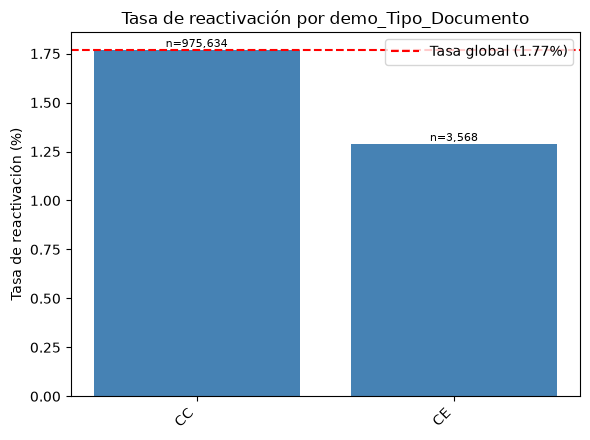

,demo_Tipo_Documento,n,reactivados,pct_poblacion,tasa_reactivacion
0,CC,975634,17247,99.64,1.77
1,CE,3568,46,0.36,1.29


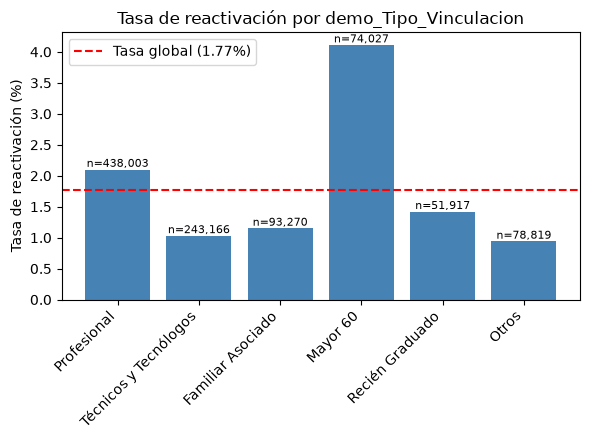

,demo_Tipo_Vinculacion,n,reactivados,pct_poblacion,tasa_reactivacion
0,Profesional,438003,9183,44.73,2.10
1,Técnicos y Tecnólogos,243166,2511,24.83,1.03
2,Familiar Asociado,93270,1076,9.53,1.15
3,Mayor 60,74027,3046,7.56,4.11
4,Recién Graduado,51917,737,5.30,1.42
5,Otros,78819,740,8.05,0.94


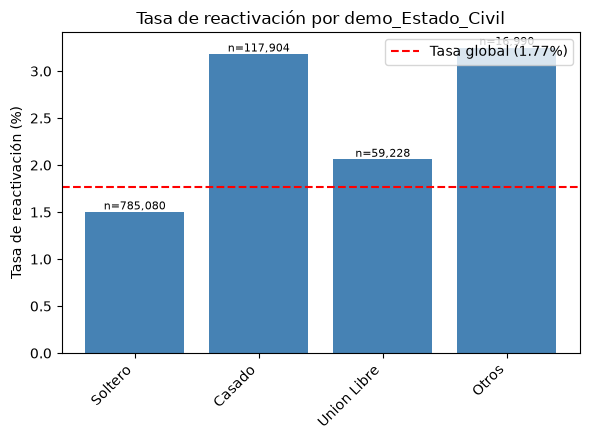

,demo_Estado_Civil,n,reactivados,pct_poblacion,tasa_reactivacion
0,Soltero,785080,11766,80.18,1.50
1,Casado,117904,3753,12.04,3.18
2,Union Libre,59228,1221,6.05,2.06
3,Otros,16990,553,1.74,3.25


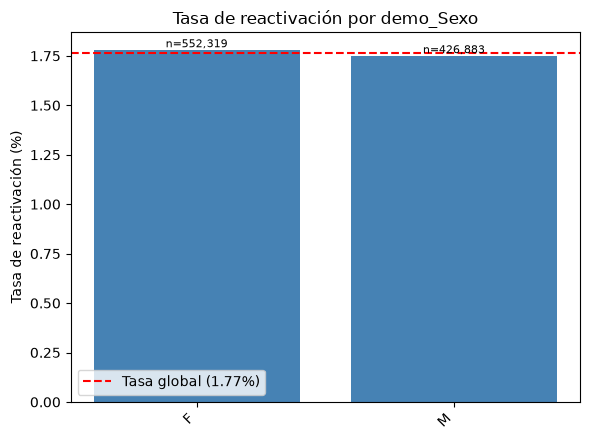

,demo_Sexo,n,reactivados,pct_poblacion,tasa_reactivacion
0,F,552319,9831,56.41,1.78
1,M,426883,7462,43.59,1.75


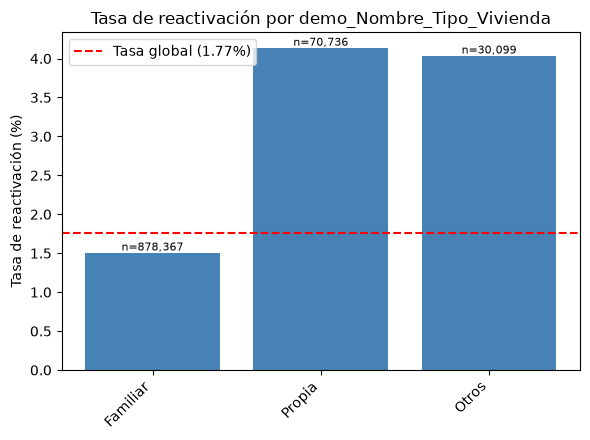

,demo_Nombre_Tipo_Vivienda,n,reactivados,pct_poblacion,tasa_reactivacion
0,Familiar,878367,13161,89.70,1.50
1,Propia,70736,2919,7.22,4.13
2,Otros,30099,1213,3.07,4.03


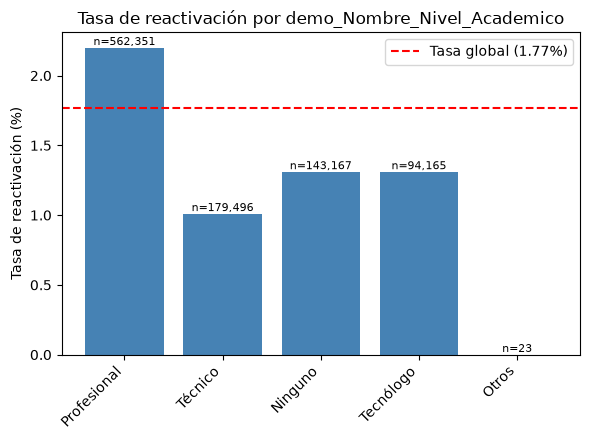

,demo_Nombre_Nivel_Academico,n,reactivados,pct_poblacion,tasa_reactivacion
0,Profesional,562351,12367,57.43,2.20
1,Técnico,179496,1816,18.33,1.01
2,Ninguno,143167,1877,14.62,1.31
3,Tecnólogo,94165,1233,9.62,1.31
4,Otros,23,0,0.00,0.00


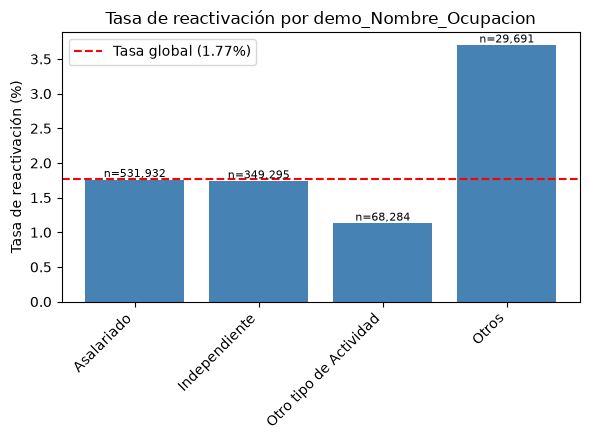

,demo_Nombre_Ocupacion,n,reactivados,pct_poblacion,tasa_reactivacion
0,Asalariado,531932,9344,54.32,1.76
1,Independiente,349295,6076,35.67,1.74
2,Otro tipo de Actividad,68284,774,6.97,1.13
3,Otros,29691,1099,3.03,3.70


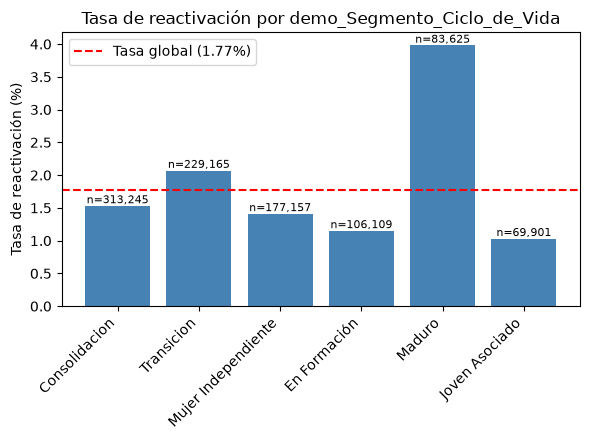

,demo_Segmento_Ciclo_de_Vida,n,reactivados,pct_poblacion,tasa_reactivacion
0,Consolidacion,313245,4793,31.99,1.53
1,Transicion,229165,4740,23.40,2.07
2,Mujer Independiente,177157,2492,18.09,1.41
3,En Formación,106109,1219,10.84,1.15
4,Maduro,83625,3331,8.54,3.98
5,Joven Asociado,69901,718,7.14,1.03


In [33]:
for col in COLS_CATEGORICAS:
     display(analizar_categorica(df, col))

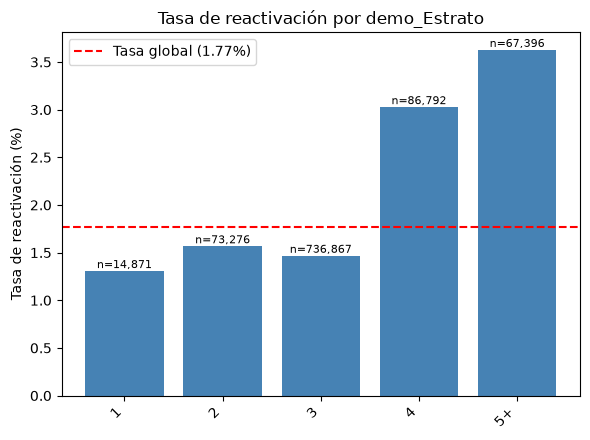

,demo_Estrato,n,reactivados,pct_poblacion,tasa_reactivacion
0,1,14871,195,1.52,1.31
1,2,73276,1154,7.48,1.57
2,3,736867,10868,75.25,1.47
3,4,86792,2631,8.86,3.03
4,5+,67396,2445,6.88,3.63


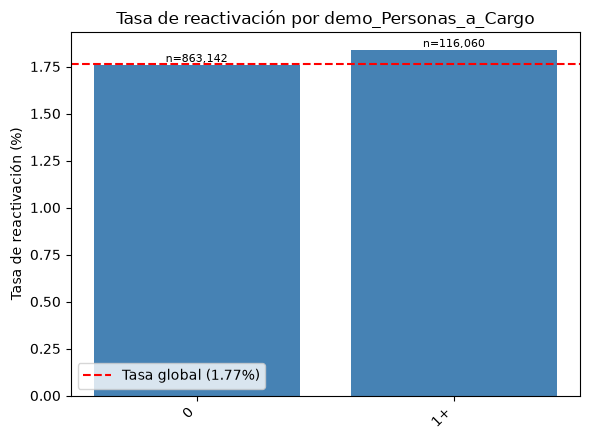

,demo_Personas_a_Cargo,n,reactivados,pct_poblacion,tasa_reactivacion
0,0,863142,15158,88.15,1.76
1,1+,116060,2135,11.85,1.84


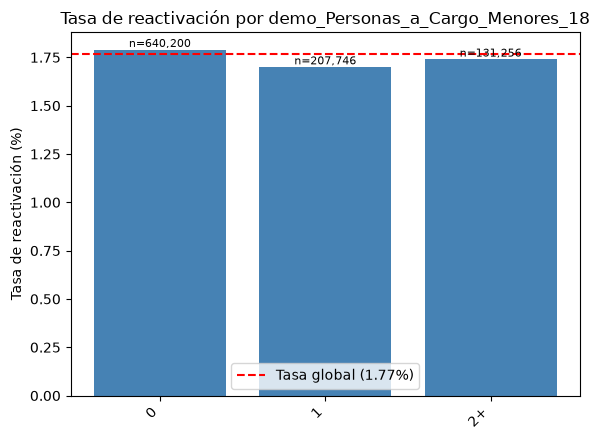

,demo_Personas_a_Cargo_Menores_18,n,reactivados,pct_poblacion,tasa_reactivacion
0,0,640200,11480,65.38,1.79
1,1,207746,3526,21.22,1.70
2,2+,131256,2287,13.40,1.74


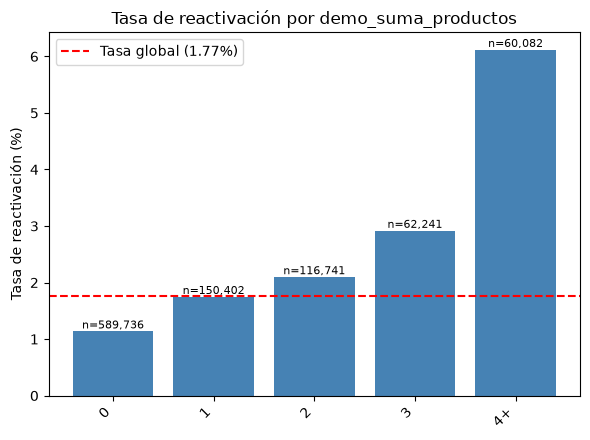

,demo_suma_productos,n,reactivados,pct_poblacion,tasa_reactivacion
0,0,589736,6712,60.23,1.14
1,1,150402,2634,15.36,1.75
2,2,116741,2451,11.92,2.10
3,3,62241,1817,6.36,2.92
4,4+,60082,3679,6.14,6.12


In [34]:
for col, tope in COLS_DISCRETAS.items():
     display(analizar_categorica(df, col, tope=tope, orden='valor'))

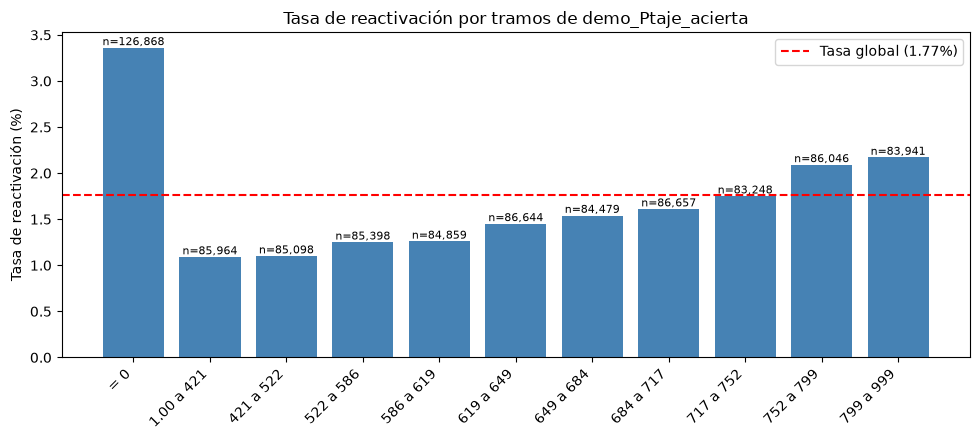

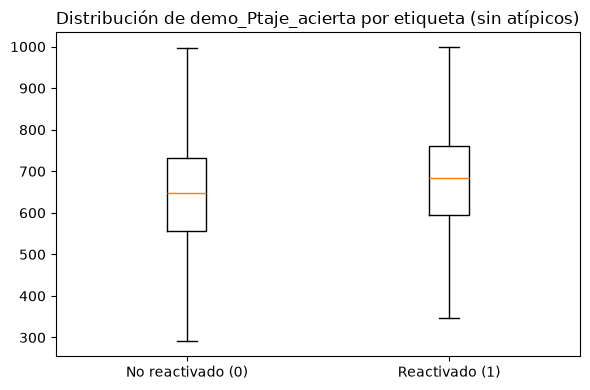

,demo_Ptaje_acierta,n,reactivados,pct_poblacion,tasa_reactivacion
0,= 0,126868,4262,12.96,3.36
1,1.00 a 421,85964,934,8.78,1.09
2,421 a 522,85098,932,8.69,1.10
3,522 a 586,85398,1067,8.72,1.25
4,586 a 619,84859,1071,8.67,1.26
5,619 a 649,86644,1258,8.85,1.45
6,649 a 684,84479,1300,8.63,1.54
7,684 a 717,86657,1397,8.85,1.61
8,717 a 752,83248,1454,8.50,1.75
9,752 a 799,86046,1797,8.79,2.09


In [21]:
analizar_numerica(df, 'demo_Ptaje_acierta', valores_especiales=[0])


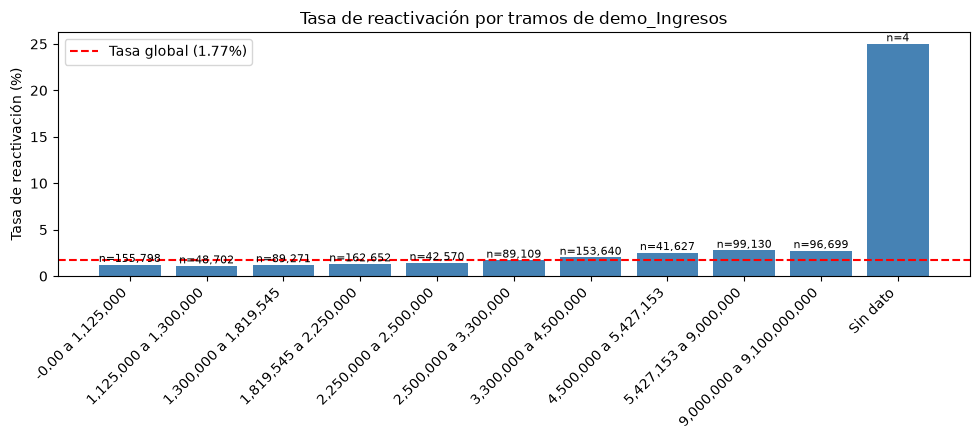

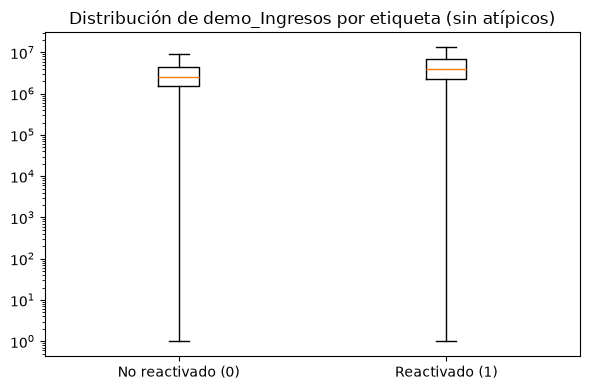

,demo_Ingresos,n,reactivados,pct_poblacion,tasa_reactivacion
0,"-0.00 a 1,125,000",155798,1931,15.91,1.24
1,"1,125,000 a 1,300,000",48702,524,4.97,1.08
2,"1,300,000 a 1,819,545",89271,1080,9.12,1.21
3,"1,819,545 a 2,250,000",162652,2122,16.61,1.30
4,"2,250,000 a 2,500,000",42570,608,4.35,1.43
5,"2,500,000 a 3,300,000",89109,1515,9.10,1.70
6,"3,300,000 a 4,500,000",153640,3089,15.69,2.01
7,"4,500,000 a 5,427,153",41627,1049,4.25,2.52
8,"5,427,153 a 9,000,000",99130,2734,10.12,2.76
9,"9,000,000 a 9,100,000,000",96699,2640,9.88,2.73


In [22]:
analizar_numerica(df, 'demo_Ingresos', log=True)

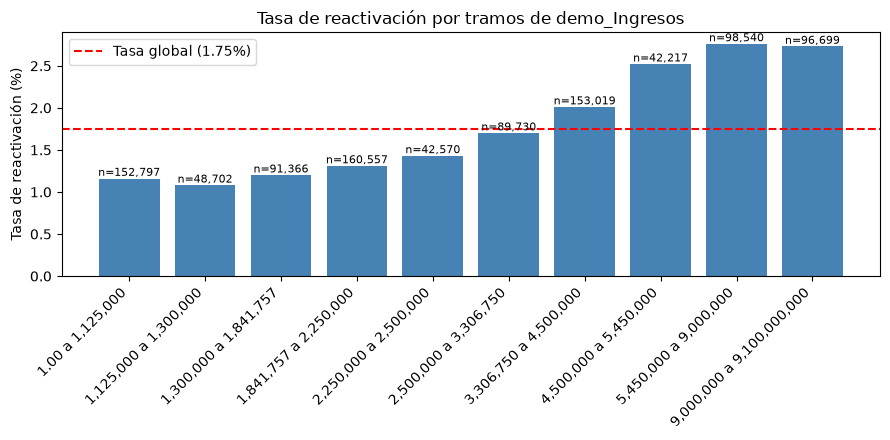

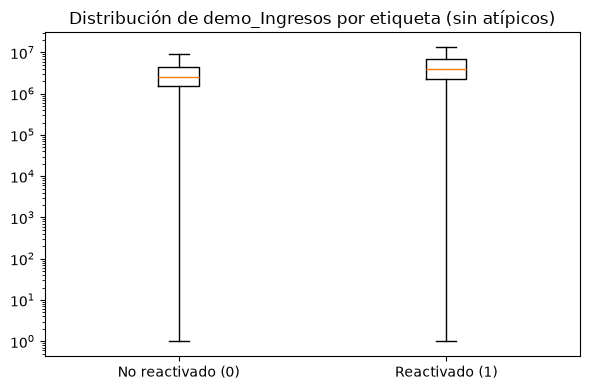

,demo_Ingresos,n,reactivados,pct_poblacion,tasa_reactivacion
0,"1.00 a 1,125,000",152797,1765,15.65,1.16
1,"1,125,000 a 1,300,000",48702,524,4.99,1.08
2,"1,300,000 a 1,841,757",91366,1098,9.36,1.20
3,"1,841,757 a 2,250,000",160557,2104,16.45,1.31
4,"2,250,000 a 2,500,000",42570,608,4.36,1.43
5,"2,500,000 a 3,306,750",89730,1522,9.19,1.70
6,"3,306,750 a 4,500,000",153019,3082,15.68,2.01
7,"4,500,000 a 5,450,000",42217,1064,4.32,2.52
8,"5,450,000 a 9,000,000",98540,2719,10.09,2.76
9,"9,000,000 a 9,100,000,000",96699,2640,9.91,2.73


In [35]:
df_ingresos = df[df['demo_Ingresos'] > 0]
analizar_numerica(df_ingresos, 'demo_Ingresos', log=True)

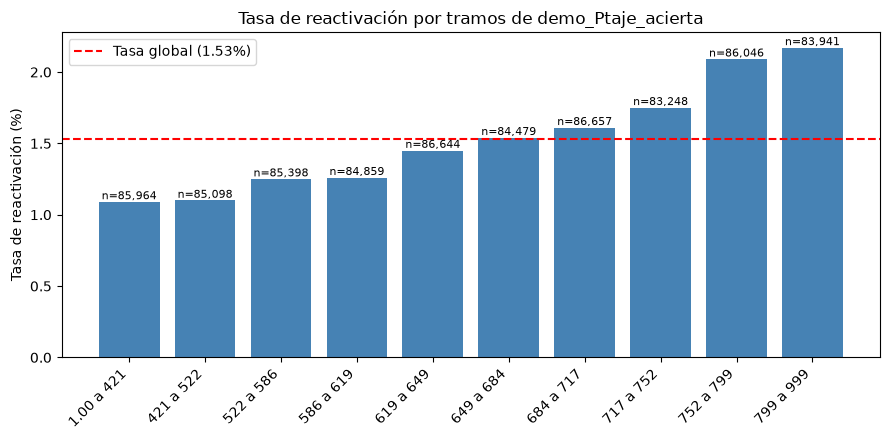

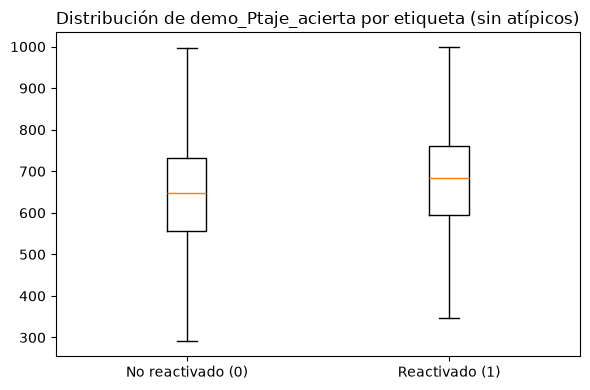

,demo_Ptaje_acierta,n,reactivados,pct_poblacion,tasa_reactivacion
0,1.00 a 421,85964,934,10.09,1.09
1,421 a 522,85098,932,9.98,1.10
2,522 a 586,85398,1067,10.02,1.25
3,586 a 619,84859,1071,9.96,1.26
4,619 a 649,86644,1258,10.17,1.45
5,649 a 684,84479,1300,9.91,1.54
6,684 a 717,86657,1397,10.17,1.61
7,717 a 752,83248,1454,9.77,1.75
8,752 a 799,86046,1797,10.10,2.09
9,799 a 999,83941,1821,9.85,2.17


In [36]:
df_ptaje = df[df['demo_Ptaje_acierta'] > 0]
analizar_numerica(df_ptaje, 'demo_Ptaje_acierta', valores_especiales=[0])